# Sanity Check - Step 06: ICA Artifact Removal

Überprüft:
- ICA Komponenten identifiziert
- EOG Artefakte erkannt
- Vorher/Nachher Signalqualität
- Amplituden-Reduktion durch ICA

In [1]:
import importlib
import os
import sys
from pathlib import Path
import mne
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

try:
    from eeg_pipeline import config
except ModuleNotFoundError:
    PIPELINE_DIR = ROOT / 'eeg_pipeline'
    if not PIPELINE_DIR.exists():
        PIPELINE_DIR = ROOT.parent / 'eeg_pipeline'
    if str(PIPELINE_DIR) not in sys.path:
        sys.path.insert(0, str(PIPELINE_DIR))
    config = importlib.import_module('config')

print('Setup erfolgreich')
print(f'Gefundene Subjects in config: {config.SUBJECTS}')

Setup erfolgreich
Gefundene Subjects in config: ['01', '02', '03']


In [2]:
# Manuelle Auswahl fuer diesen Notebook-Run
subject_id = "03"  # z.B. "02"
person = "P1"  # "P1" oder "P2"
if person not in {"P1", "P2"}:
    raise ValueError("person muss P1 oder P2 sein")
os.environ["EEG_SUBJECT"] = subject_id
os.environ["EEG_PERSON"] = person
print(f"Manuell gesetzt: EEG_SUBJECT={os.environ['EEG_SUBJECT']}, EEG_PERSON={os.environ['EEG_PERSON']}")

Manuell gesetzt: EEG_SUBJECT=03, EEG_PERSON=P1


## 1. Before & After laden

In [3]:
subject_from_env = os.getenv('EEG_SUBJECT')
subject_default = globals().get('subject_id', subject_from_env or (config.SUBJECTS[0] if config.SUBJECTS else None))
if subject_default is None:
    raise ValueError('Kein Subject gefunden. Setze subject_id in der Zelle oder EEG_SUBJECT als Umgebungsvariable.')

subject_id = str(subject_default)
if subject_id.isdigit() and len(subject_id) == 1:
    subject_id = subject_id.zfill(2)

person = globals().get('person', os.getenv('EEG_PERSON', 'P1')).upper()
if person not in ['P1', 'P2']:
    raise ValueError("person muss 'P1' oder 'P2' sein")

before_path = config.OUTPUT_DIR / f"sub-{subject_id}_{person}_filtered.fif"
after_path = config.OUTPUT_DIR / f"sub-{subject_id}_{person}_ica_cleaned.fif"
ica_path = config.QC_DIR / f"sub-{subject_id}_{person}_ica.fif"

print(f'Nutze subject_id={subject_id}, person={person}')

if not before_path.exists() or not after_path.exists():
    raise FileNotFoundError(f'Fehlende Dateien: {before_path} oder {after_path}')

raw_before = mne.io.read_raw_fif(str(before_path), preload=False)
raw_after = mne.io.read_raw_fif(str(after_path), preload=False)
print(f"✓ Both files loaded for {person}")

ica = None
if ica_path.exists():
    ica = mne.preprocessing.read_ica(str(ica_path))
    print(f"✓ ICA decomposition loaded")
    print(f"  Components: {ica.n_components_}")
    print(f"  Excluded: {len(ica.exclude)}")
else:
    print(f"INFO: Keine ICA-Datei gefunden unter {ica_path}")

Nutze subject_id=03, person=P1
Opening raw data file c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-03_P1_filtered.fif...
    Range : 0 ... 753199 =      0.000 ...  3765.995 secs
Ready.
Opening raw data file c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-03_P1_ica_cleaned.fif...
    Range : 0 ... 753199 =      0.000 ...  3765.995 secs
Ready.
✓ Both files loaded for P1
Reading c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\qc\sub-03_P1_ica.fif ...
Now restoring ICA solution ...
Ready.
✓ ICA decomposition loaded
  Components: 20
  Excluded: 1


C:\Users\BKALYON\AppData\Local\Temp\ipykernel_29292\3680508390.py:23: RuntimeWarning: This filename (c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-03_P1_filtered.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_before = mne.io.read_raw_fif(str(before_path), preload=False)
C:\Users\BKALYON\AppData\Local\Temp\ipykernel_29292\3680508390.py:24: RuntimeWarning: This filename (c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-03_P1_ica_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_after = mne.io.read_raw_fif(str(after_path), preload=False)


## 2. Metadata Überprüfung

In [4]:
print(f"=== VORHER (Gefiltert) ===")
print(f"Kanäle: {len(raw_before.ch_names)}")
print(f"  EEG: {len(mne.pick_types(raw_before.info, eeg=True))}")
print(f"  EOG: {len(mne.pick_types(raw_before.info, eog=True))}")
print(f"Dauer: {raw_before.times[-1]:.2f}s")

print(f"\n=== NACHHER (ICA Cleaned) ===")
print(f"Kanäle: {len(raw_after.ch_names)}")
print(f"  EEG: {len(mne.pick_types(raw_after.info, eeg=True))}")
print(f"  EOG: {len(mne.pick_types(raw_after.info, eog=True))}")
print(f"Dauer: {raw_after.times[-1]:.2f}s")

print(f"\n=== VALIDIERUNGEN ===")
if len(raw_before.ch_names) == len(raw_after.ch_names):
    print(f"✓ Kanal-Anzahl erhalten")
if raw_before.n_times == raw_after.n_times:
    print(f"✓ Sample-Anzahl erhalten")

=== VORHER (Gefiltert) ===
Kanäle: 72
  EEG: 64
  EOG: 2
Dauer: 3765.99s

=== NACHHER (ICA Cleaned) ===
Kanäle: 72
  EEG: 64
  EOG: 2
Dauer: 3765.99s

=== VALIDIERUNGEN ===
✓ Kanal-Anzahl erhalten
✓ Sample-Anzahl erhalten


## 3. Amplituden-Vergleich

In [5]:
eeg_picks = mne.pick_types(raw_before.info, eeg=True)
t_end = min(120, raw_before.times[-1])
t_idx_end = int(t_end * raw_before.info['sfreq'])

data_before = raw_before.get_data(picks=eeg_picks, start=0, stop=t_idx_end)
data_after = raw_after.get_data(picks=eeg_picks, start=0, stop=t_idx_end)

std_before = np.std(data_before)
std_after = np.std(data_after)
change = (std_after/std_before - 1) * 100

print(f"EEG Amplituden (erste 120s):")
print(f"  VORHER: {std_before:.6f} µV (Std)")
print(f"  NACHHER: {std_after:.6f} µV (Std)")
print(f"  Change: {change:+.1f}%")

# EOG
eog_picks = mne.pick_types(raw_before.info, eog=True)
if len(eog_picks) > 0:
    eog_data_before = raw_before.get_data(picks=eog_picks, start=0, stop=t_idx_end)
    eog_data_after = raw_after.get_data(picks=eog_picks, start=0, stop=t_idx_end)
    
    eog_std_before = np.std(eog_data_before)
    eog_std_after = np.std(eog_data_after)
    eog_reduction = (1 - eog_std_after/eog_std_before) * 100
    
    print(f"\nEOG Amplituden (Augenbewegungen):")
    print(f"  VORHER: {eog_std_before:.6f} µV (Std)")
    print(f"  NACHHER: {eog_std_after:.6f} µV (Std)")
    print(f"  Reduktion: {eog_reduction:.1f}%")

EEG Amplituden (erste 120s):
  VORHER: 0.000034 µV (Std)
  NACHHER: 0.000119 µV (Std)
  Change: +244.9%

EOG Amplituden (Augenbewegungen):
  VORHER: 0.044733 µV (Std)
  NACHHER: 0.044733 µV (Std)
  Reduktion: 0.0%


## 4. Gezielte ICA-QC Plots
Nur ICA-spezifische Qualitätssicherung:
- Topomaps der ausgeschlossenen ICA-Komponenten
- Blink-locked EEG GFP (vorher/nachher)
- Frontaler EEG-Overlay (vorher/nachher)

✓ Excluded-component Topomaps gespeichert (1 Datei(en))


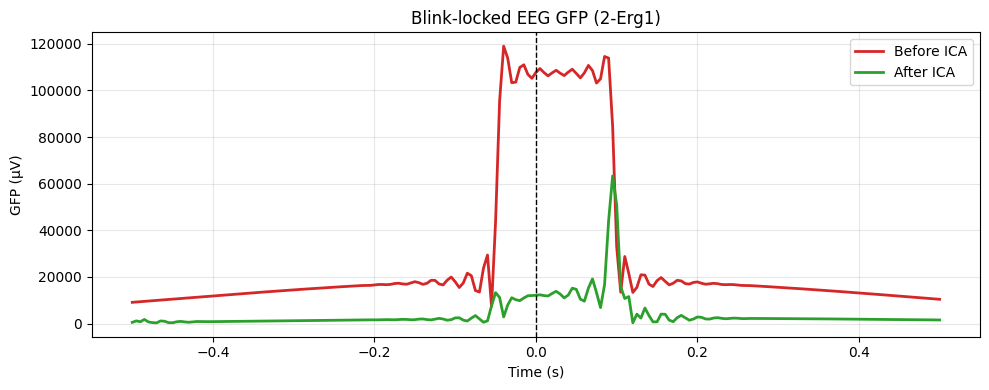

✓ Blink-locked GFP gespeichert


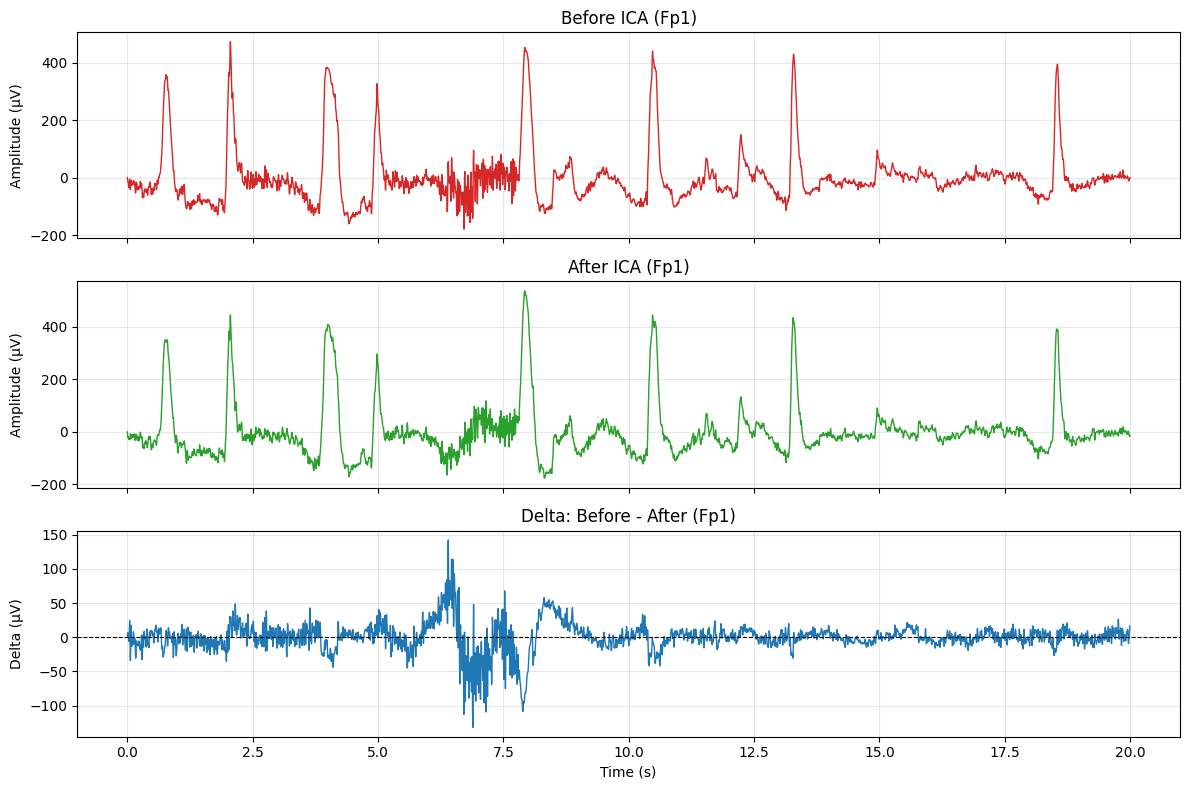

✓ Frontaler QC gespeichert (Fp1)


In [6]:
# 1) Topomaps der ausgeschlossenen ICA-Komponenten
if ica is not None and len(ica.exclude) > 0:
    figs = ica.plot_components(picks=ica.exclude, show=False)
    if not isinstance(figs, list):
        figs = [figs]

    for idx, fig in enumerate(figs, start=1):
        out = config.QC_DIR / f'sub-{subject_id}_{person}_ica_excluded_components_{idx}.png'
        fig.savefig(out, dpi=120, bbox_inches='tight')
        plt.close(fig)
    print(f'✓ Excluded-component Topomaps gespeichert ({len(figs)} Datei(en))')
else:
    print('INFO: Keine ICA-Komponenten als excluded markiert oder keine ICA-Datei geladen')

# 2) Blink-locked EEG GFP: gleiche Blink-Events vorher/nachher (robust)
blink_done = False
eog_picks = mne.pick_types(raw_before.info, eog=True)
if len(eog_picks) > 0:
    eog_name = raw_before.ch_names[eog_picks[0]]
    eog_events = mne.preprocessing.find_eog_events(raw_before, ch_name=eog_name, verbose=False)
    eeg_picks = mne.pick_types(raw_before.info, eeg=True)

    if len(eog_events) > 0 and len(eeg_picks) > 0:
        sfreq = raw_before.info['sfreq']
        tmin = -0.5
        tmax = 0.5
        n_pre = int(abs(tmin) * sfreq)
        n_post = int(tmax * sfreq)
        win_len = n_pre + n_post + 1

        eeg_before_all = raw_before.get_data(picks=eeg_picks)
        eeg_after_all = raw_after.get_data(picks=eeg_picks)

        segments_before = []
        segments_after = []
        for event_sample in eog_events[:, 0]:
            start = int(event_sample) - n_pre
            stop = int(event_sample) + n_post + 1
            if start < 0 or stop > eeg_before_all.shape[1]:
                continue
            segments_before.append(eeg_before_all[:, start:stop])
            segments_after.append(eeg_after_all[:, start:stop])

        if len(segments_before) > 0:
            arr_before = np.stack(segments_before, axis=0)
            arr_after = np.stack(segments_after, axis=0)

            evoked_before = arr_before.mean(axis=0)
            evoked_after = arr_after.mean(axis=0)
            gfp_before_uv = evoked_before.std(axis=0) * 1e6
            gfp_after_uv = evoked_after.std(axis=0) * 1e6
            times = np.linspace(tmin, tmax, win_len)

            fig, ax = plt.subplots(1, 1, figsize=(10, 4))
            ax.plot(times, gfp_before_uv, label='Before ICA', color='tab:red', linewidth=2)
            ax.plot(times, gfp_after_uv, label='After ICA', color='tab:green', linewidth=2)
            ax.axvline(0, color='k', linestyle='--', linewidth=1)
            ax.set_title(f'Blink-locked EEG GFP ({eog_name})')
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('GFP (µV)')
            ax.legend()
            ax.grid(alpha=0.3)
            plt.tight_layout()
            out = config.QC_DIR / f'sub-{subject_id}_{person}_ica_blink_locked_gfp.png'
            fig.savefig(out, dpi=120, bbox_inches='tight')
            plt.show()
            print('✓ Blink-locked GFP gespeichert')
            blink_done = True

if not blink_done:
    print('INFO: Kein nutzbarer EOG-Blink-Event für blink-locked QC gefunden')

# 3) Frontaler EEG-Kanal: getrennte Vorher/Nachher-Plots + Delta
eeg_names = [raw_before.ch_names[i] for i in mne.pick_types(raw_before.info, eeg=True)]
preferred = ['Fp1', 'Fpz', 'Fp2', 'AFz', 'Fz']
frontal_ch = next((ch for ch in preferred if ch in eeg_names), eeg_names[0] if eeg_names else None)

if frontal_ch is not None:
    sfreq = raw_before.info['sfreq']
    duration_sec = min(20, raw_before.times[-1])
    stop_idx = int(duration_sec * sfreq)
    times = np.arange(stop_idx) / sfreq

    before_uv = raw_before.get_data(picks=[frontal_ch], start=0, stop=stop_idx)[0] * 1e6
    after_uv = raw_after.get_data(picks=[frontal_ch], start=0, stop=stop_idx)[0] * 1e6
    delta_uv = before_uv - after_uv

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(times, before_uv, color='tab:red', linewidth=1)
    axes[0].set_title(f'Before ICA ({frontal_ch})')
    axes[0].set_ylabel('Amplitude (µV)')
    axes[0].grid(alpha=0.3)

    axes[1].plot(times, after_uv, color='tab:green', linewidth=1)
    axes[1].set_title(f'After ICA ({frontal_ch})')
    axes[1].set_ylabel('Amplitude (µV)')
    axes[1].grid(alpha=0.3)

    axes[2].plot(times, delta_uv, color='tab:blue', linewidth=1)
    axes[2].axhline(0, color='k', linestyle='--', linewidth=0.8)
    axes[2].set_title(f'Delta: Before - After ({frontal_ch})')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Delta (µV)')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    out = config.QC_DIR / f'sub-{subject_id}_{person}_ica_frontal_qc_{frontal_ch}.png'
    fig.savefig(out, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'✓ Frontaler QC gespeichert ({frontal_ch})')
else:
    print('INFO: Keine EEG-Kanäle gefunden, QC übersprungen')